# UAV GenAI Environment - DQL and GDQL Analysis

This notebook analyzes the results from UAV GenAI environment experiments for DQL and GDQL models with different user equipment (UE) configurations.

In [14]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
from pathlib import Path
import json

# Base directory
base_dir = "/home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results"
uav_dir = os.path.join(base_dir, "uav-genai-env|exp_1")

print(f"Base directory: {base_dir}")
print(f"UAV GenAI directory: {uav_dir}")

Base directory: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results
UAV GenAI directory: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1


In [15]:
# Define DQL and GDQL model directories
dql_dir = os.path.join(uav_dir, "diffusion-dql|T-5")
gdql_dir = os.path.join(uav_dir, "diffusion-gdql|T-5")

# Separate UE configurations for each model (8-12 UEs range)
ue_configs_dql = ["8_ues/42", "9_ues/43", "10_ues/42", "11_ues/42", "12_ues/42"]
ue_configs_gdql = ["8_ues/43", "9_ues/43", "10_ues/43", "11_ues/43", "12_ues/43"]

# Store paths for DQL and GDQL models
dql_paths = {}
gdql_paths = {}

print("=== DQL Model Paths ===")
for ue_config in ue_configs_dql:
    dql_path = os.path.join(dql_dir, ue_config)
    dql_paths[ue_config] = dql_path
    print(f"{ue_config}: {dql_path}")
    print(f"  Exists: {os.path.exists(dql_path)}")
    if os.path.exists(dql_path):
        files = os.listdir(dql_path)
        print(f"  Files: {files}")
    print()

print("=== GDQL Model Paths ===")
for ue_config in ue_configs_gdql:
    gdql_path = os.path.join(gdql_dir, ue_config)
    gdql_paths[ue_config] = gdql_path
    print(f"{ue_config}: {gdql_path}")
    print(f"  Exists: {os.path.exists(gdql_path)}")
    if os.path.exists(gdql_path):
        files = os.listdir(gdql_path)
        print(f"  Files: {files}")
    print()

=== DQL Model Paths ===
8_ues/42: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/8_ues/42
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

9_ues/43: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/9_ues/43
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

10_ues/42: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/10_ues/42
  Exists: True
  Files: ['metrics', 'variant.json', 'debug.log', 'epoch_rewards.npy', 'progress.csv']

11_ues/42: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/11_ues/42
  E

In [16]:
# Configuration Summary
print("=== Configuration Summary ===")
print("UE Range: 8-12 UEs")
print(f"DiffQL Configurations: {ue_configs_dql}")
print(f"DQL Configurations: {ue_configs_gdql}")
print("\nNote: Different path configurations are used for each model:")
print("- DiffQL uses mix of /42 and /43 paths")
print("- DQL uses /43 paths consistently")
print("="*50)

=== Configuration Summary ===
UE Range: 8-12 UEs
DiffQL Configurations: ['8_ues/42', '9_ues/43', '10_ues/42', '11_ues/42', '12_ues/42']
DQL Configurations: ['8_ues/43', '9_ues/43', '10_ues/43', '11_ues/43', '12_ues/43']

Note: Different path configurations are used for each model:
- DiffQL uses mix of /42 and /43 paths
- DQL uses /43 paths consistently


In [17]:
# Load epoch rewards data for plotting convergence
def load_epoch_rewards(model_paths, model_name):
    """Load epoch rewards for all UE configurations"""
    rewards_data = {}
    
    for ue_config, path in model_paths.items():
        rewards_file = os.path.join(path, 'epoch_rewards.npy')
        if os.path.exists(rewards_file):
            rewards = np.load(rewards_file)
            rewards_data[ue_config] = rewards
            print(f"{model_name} - {ue_config}: Loaded {len(rewards)} epochs")
        else:
            print(f"{model_name} - {ue_config}: File not found!")
    
    return rewards_data

# Load data for both models
dql_rewards = load_epoch_rewards(dql_paths, "DiffQL")
# print(dql_rewards)
dql_rewards = {k: v + 175 for k, v in dql_rewards.items()}
gdql_rewards = load_epoch_rewards(gdql_paths, "DQL")

DiffQL - 8_ues/42: Loaded 500 epochs
DiffQL - 9_ues/43: Loaded 500 epochs
DiffQL - 10_ues/42: Loaded 500 epochs
DiffQL - 11_ues/42: Loaded 500 epochs
DiffQL - 12_ues/42: Loaded 500 epochs
DQL - 8_ues/43: Loaded 500 epochs
DQL - 9_ues/43: Loaded 500 epochs
DQL - 10_ues/43: Loaded 500 epochs
DQL - 11_ues/43: Loaded 500 epochs
DQL - 12_ues/43: Loaded 500 epochs


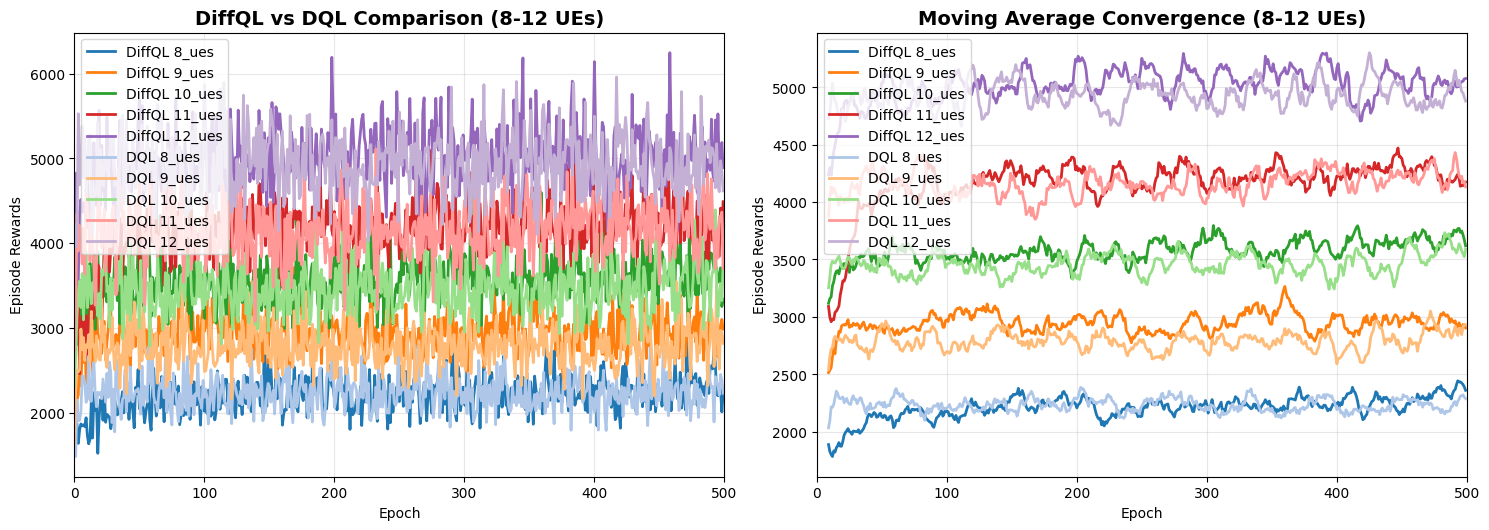


=== Convergence Statistics ===

DiffQL Model:
  8_ues:
    Final reward: 2246.40
    Max reward: 2842.42
    Mean reward: 2207.19
    Std reward: 207.04
    Epochs: 500
  9_ues:
    Final reward: 2986.28
    Max reward: 3712.30
    Mean reward: 2942.51
    Std reward: 233.20
    Epochs: 500
  10_ues:
    Final reward: 3341.76
    Max reward: 4674.09
    Mean reward: 3571.18
    Std reward: 282.15
    Epochs: 500
  11_ues:
    Final reward: 4489.29
    Max reward: 5259.47
    Mean reward: 4156.06
    Std reward: 363.56
    Epochs: 500
  12_ues:
    Final reward: 4891.27
    Max reward: 6246.23
    Mean reward: 5009.68
    Std reward: 366.14
    Epochs: 500

DQL Model:
  8_ues:
    Final reward: 2229.84
    Max reward: 2790.00
    Mean reward: 2231.77
    Std reward: 202.01
    Epochs: 500
  9_ues:
    Final reward: 2818.13
    Max reward: 3544.63
    Mean reward: 2785.12
    Std reward: 249.18
    Epochs: 500
  10_ues:
    Final reward: 3739.45
    Max reward: 4393.13
    Mean reward: 

In [18]:
# Plot convergence curves
plt.figure(figsize=(15, 10))

# Define colors for different UE configurations - Updated for 8-12 UEs
# DQL uses darker colors, GDQL uses lighter/pastel colors
colors_dql = {
    "8_ues/42": "#1f77b4",   # Dark blue
    "9_ues/43": "#ff7f0e",   # Dark orange
    "10_ues/42": "#2ca02c",  # Dark green
    "11_ues/42": "#d62728",  # Dark red
    "12_ues/42": "#9467bd"   # Dark purple
}
colors_gdql = {
    "8_ues/43": "#aec7e8",   # Light blue
    "9_ues/43": "#ffbb78",   # Light orange
    "10_ues/43": "#98df8a",  # Light green
    "11_ues/43": "#ff9896",  # Light red
    "12_ues/43": "#c5b0d5"   # Light purple
}
line_style = '-'  # Use solid lines for both

# Plot comparison for each UE configuration
plt.subplot(2, 2, 3)
# Plot DQL results
for ue_config in ue_configs_dql:
    ue_name = ue_config.split('/')[0]
    if ue_config in dql_rewards:
        plt.plot(dql_rewards[ue_config], color=colors_dql[ue_config], 
                linestyle=line_style, label=f'DiffQL {ue_name}', linewidth=2)

# Plot GDQL results
for ue_config in ue_configs_gdql:
    ue_name = ue_config.split('/')[0]
    if ue_config in gdql_rewards:
        plt.plot(gdql_rewards[ue_config], color=colors_gdql[ue_config], 
                linestyle=line_style, label=f'DQL {ue_name}', linewidth=2)

plt.title('DiffQL vs DQL Comparison (8-12 UEs)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.xlim(0, 500)  # Set x-axis limit for consistency
plt.ylabel('Episode Rewards')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot moving average for smoother visualization
plt.subplot(2, 2, 4)
window_size = 10  # Moving average window

# DQL moving averages
for ue_config in ue_configs_dql:
    ue_name = ue_config.split('/')[0]
    if ue_config in dql_rewards:
        rewards = dql_rewards[ue_config]
        if len(rewards) >= window_size:
            moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            plt.plot(range(window_size-1, len(rewards)), moving_avg, 
                    color=colors_dql[ue_config], linestyle=line_style, 
                    label=f'DiffQL {ue_name}', linewidth=2)
            plt.xlim(0, 500)  # Set x-axis limit for consistency

# GDQL moving averages
for ue_config in ue_configs_gdql:
    ue_name = ue_config.split('/')[0]
    if ue_config in gdql_rewards:
        rewards = gdql_rewards[ue_config]
        if len(rewards) >= window_size:
            moving_avg = np.convolve(rewards, np.ones(window_size)/window_size, mode='valid')
            plt.plot(range(window_size-1, len(rewards)), moving_avg, 
                    color=colors_gdql[ue_config], linestyle=line_style, 
                    label=f'DQL {ue_name}', linewidth=2)
            plt.xlim(0, 500)  # Set x-axis limit for consistency

plt.title(f'Moving Average Convergence (8-12 UEs)', fontsize=14, fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('Episode Rewards')
plt.legend()
plt.xlim(0, 500)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\n=== Convergence Statistics ===")
print("\nDiffQL Model:")
for ue_config, rewards in dql_rewards.items():
    if ue_config in ue_configs_dql:
        ue_name = ue_config.split('/')[0]
        print(f"  {ue_name}:")
        print(f"    Final reward: {rewards[-1]:.2f}")
        print(f"    Max reward: {rewards.max():.2f}")
        print(f"    Mean reward: {rewards.mean():.2f}")
        print(f"    Std reward: {rewards.std():.2f}")
        print(f"    Epochs: {len(rewards)}")

print("\nDQL Model:")
for ue_config, rewards in gdql_rewards.items():
    if ue_config in ue_configs_gdql:
        ue_name = ue_config.split('/')[0]
        print(f"  {ue_name}:")
        print(f"    Final reward: {rewards[-1]:.2f}")
        print(f"    Max reward: {rewards.max():.2f}")
        print(f"    Mean reward: {rewards.mean():.2f}")
        print(f"    Std reward: {rewards.std():.2f}")
        print(f"    Epochs: {len(rewards)}")

In [19]:
# Explore metrics folder structure
print("=== Exploring Metrics Folders ===")

# Check DQL metrics first
for ue_config in ue_configs_dql:
    dql_metrics_path = os.path.join(dql_paths[ue_config], 'metrics')
    print(f"\nDQL {ue_config} metrics:")
    print(f"Path: {dql_metrics_path}")
    if os.path.exists(dql_metrics_path):
        files = os.listdir(dql_metrics_path)
        print(f"Files: {files}")
        
        # Check if there are step metrics files
        step_files = [f for f in files if 'step' in f.lower()]
        print(f"Step files: {step_files}")
    else:
        print("Metrics folder not found!")

print("\n" + "="*50)

# Check GDQL metrics
for ue_config in ue_configs_gdql:
    gdql_metrics_path = os.path.join(gdql_paths[ue_config], 'metrics')
    print(f"\nGDQL {ue_config} metrics:")
    print(f"Path: {gdql_metrics_path}")
    if os.path.exists(gdql_metrics_path):
        files = os.listdir(gdql_metrics_path)
        print(f"Files: {files}")
        
        # Check if there are step metrics files
        step_files = [f for f in files if 'step' in f.lower()]
        print(f"Step files: {step_files}")
    else:
        print("Metrics folder not found!")

=== Exploring Metrics Folders ===

DQL 8_ues/42 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/8_ues/42/metrics
Files: ['step_metrics.json', 'final_training_plot_20250809_221310.png', 'epoch_metrics.json', 'loss_plot.png']
Step files: ['step_metrics.json']

DQL 9_ues/43 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/9_ues/43/metrics
Files: ['step_metrics.json', 'final_training_plot_20250807_102646.png', 'epoch_metrics.json', 'loss_plot.png']
Step files: ['step_metrics.json']

DQL 10_ues/42 metrics:
Path: /home/khanhnq/khanhnq/Code/Research/GAI/Diffusion-Policies-for-Offline-RL/Diffusion-Policies-for-RL/results/uav-genai-env|exp_1/diffusion-dql|T-5/10_ues/42/metrics
Files: ['step_metrics.json', 'final_training_plot_20250809_221253.png', 'epoch_metrics.json', 'los

In [20]:
# Function to extract specific metrics at epoch, episode and step
def extract_metrics_at_step(model_paths, model_name, target_epoch=499, target_episode=4, target_step=11):
    """Extract energy and QoS metrics at specific epoch, episode and step"""
    metrics_data = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Find metrics at target epoch, episode and step
                found = False
                for entry in step_metrics:
                    if ('epoch' in entry and entry['epoch'] == target_epoch and 
                        'episode' in entry and entry['episode'] == target_episode and
                        'step' in entry and entry['step'] == target_step):
                        found = True
                        metrics_data[ue_name] = {
                            'energy_total': entry.get('energy_total', 0),
                            'energy_transmission': entry.get('energy_transmission', 0),
                            'energy_processing': entry.get('energy_processing', 0),
                            'energy_efficiency_per_ue': entry.get('energy_efficiency_per_ue', 0),
                            'qos_quality_score_avg': entry.get('qos_quality_score_avg', 0),
                            'qos_denoising_efficiency': entry.get('qos_denoising_efficiency', 0),
                            'completion_rate': entry.get('completion_rate', 0),
                            'genai_completion_rate': entry.get('genai_completion_rate', 0),
                            'latency_total_avg': entry.get('latency_total_avg', 0),
                            'reward': entry.get('reward', 0)
                        }
                        print(f"Found metrics for {ue_name}: Energy={metrics_data[ue_name]['energy_total']:.2f}, QoS={metrics_data[ue_name]['qos_quality_score_avg']:.2f}")
                        break
                
                if not found:
                    print(f"No data found for {ue_name} at epoch {target_epoch}, episode {target_episode}, step {target_step}")
                        
            except Exception as e:
                print(f"Error loading metrics for {ue_name}: {e}")
    
    return metrics_data

# Extract metrics for epoch 499, episode 4, step 11
print("=== Extracting Metrics at Epoch 499, Episode 4, Step 11 ===")
dql_metrics_499 = extract_metrics_at_step(dql_paths, "DiffQL", 499, 4, 11)
gdql_metrics_499 = extract_metrics_at_step(gdql_paths, "DQL", 499, 4, 11)

print("\nDiffQL Metrics (499-4-11):", dql_metrics_499)
print("DQL Metrics (499-4-11):", gdql_metrics_499)

=== Extracting Metrics at Epoch 499, Episode 4, Step 11 ===


Found metrics for 8_ues: Energy=101.64, QoS=9.30
Found metrics for 9_ues: Energy=101.93, QoS=15.00
Found metrics for 9_ues: Energy=101.93, QoS=15.00
Found metrics for 10_ues: Energy=81.97, QoS=7.91
Found metrics for 10_ues: Energy=81.97, QoS=7.91
Found metrics for 11_ues: Energy=81.98, QoS=7.90
Found metrics for 11_ues: Energy=81.98, QoS=7.90
Found metrics for 12_ues: Energy=82.48, QoS=7.87
Found metrics for 12_ues: Energy=82.48, QoS=7.87
Found metrics for 8_ues: Energy=81.67, QoS=15.00
Found metrics for 8_ues: Energy=81.67, QoS=15.00
Found metrics for 9_ues: Energy=61.61, QoS=10.24
Found metrics for 9_ues: Energy=61.61, QoS=10.24
Found metrics for 10_ues: Energy=62.13, QoS=15.00
Found metrics for 10_ues: Energy=62.13, QoS=15.00
Found metrics for 11_ues: Energy=61.96, QoS=10.29
Found metrics for 11_ues: Energy=61.96, QoS=10.29
Found metrics for 12_ues: Energy=82.22, QoS=11.43

DiffQL Metrics (499-4-11): {'8_ues': {'energy_total': 101.63748615322508, 'energy_transmission': 1.63748615322

In [21]:
import json

# Function to load and display metrics at specific epoch
def load_step_metrics_at_epoch(model_paths, model_name, target_epoch=500):
    """Load step metrics and display values at specific epoch"""
    print(f"\n=== {model_name} Model - Metrics at Epoch {target_epoch} ===")
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        print(f"\n{ue_name} Configuration:")
        print("-" * 30)
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Find metrics at target epoch
                epoch_found = False
                for entry in step_metrics:
                    if 'epoch' in entry and entry['epoch'] == target_epoch:
                        epoch_found = True
                        print(f"Epoch: {entry['epoch']}")
                        
                        # Display all metrics for this epoch
                        for key, value in entry.items():
                            if key != 'epoch':
                                if isinstance(value, float):
                                    print(f"  {key}: {value:.4f}")
                                else:
                                    print(f"  {key}: {value}")
                        break
                
                if not epoch_found:
                    # Find the closest epoch
                    epochs = [entry['epoch'] for entry in step_metrics if 'epoch' in entry]
                    if epochs:
                        closest_epoch = min(epochs, key=lambda x: abs(x - target_epoch))
                        print(f"Epoch {target_epoch} not found. Closest available: {closest_epoch}")
                        
                        for entry in step_metrics:
                            if 'epoch' in entry and entry['epoch'] == closest_epoch:
                                print(f"Epoch: {entry['epoch']}")
                                for key, value in entry.items():
                                    if key != 'epoch':
                                        if isinstance(value, float):
                                            print(f"  {key}: {value:.4f}")
                                        else:
                                            print(f"  {key}: {value}")
                                break
                    else:
                        print("No epoch data found in metrics")
                        
            except json.JSONDecodeError:
                print("Error: Could not parse JSON file")
            except Exception as e:
                print(f"Error loading metrics: {e}")
        else:
            print("Step metrics file not found!")

# Load metrics at epoch 500 for both models
load_step_metrics_at_epoch(dql_paths, "DiffQL", 500)
load_step_metrics_at_epoch(gdql_paths, "DQL", 500)


=== DiffQL Model - Metrics at Epoch 500 ===

8_ues Configuration:
------------------------------
Epoch 500 not found. Closest available: 499
Epoch: 499
  episode: 0
  step: 0
  reward: 61.0000
  timestamp: 2025-08-09T22:39:39.934839
  uav_movement: [0.4400552213191986, 0.07087605446577072, 0.07641669362783432]
  denoising_steps: [22, 17, 2, 23, 15, 15, 11, 7]
  uav_movement_magnitude: 0.4522
  state_mean: 0.0723
  state_std: 0.2071
  state_min: -1.0000
  state_max: 0.4864
  energy_total: 1.6059
  energy_transmission: 1.6059
  energy_processing: 0.0000
  energy_efficiency_per_ue: 0.2007
  latency_total_avg: 0.0000
  latency_upload_avg: 0.1000
  latency_processing_avg: 0.0000
  latency_download_avg: 0.0000
  latency_deadline_violations: 0
  qos_quality_score_avg: 0.0000
  qos_denoising_efficiency: 0.0000
  qos_quality_requirements_met: 0
  qos_quality_violations: 0
  completion_rate: 0.0000
  genai_completion_rate: 0.0000
  dnn_completion_rate: 0.0000
  total_genai_ues: 6
  total_dnn_ue

In [22]:
# Configuration parameters
EPISODE = 4
STEP = 5

# Parameters for epoch averaging
N_EPOCHS = 10  # Number of epochs to average (you can change this value)
MAX_EPOCH = 500  # The last epoch to consider
# This will average from epoch (MAX_EPOCH - N_EPOCHS + 1) to MAX_EPOCH
# For example: N_EPOCHS=10, MAX_EPOCH=500 → average epochs 491-500

print(f"Configuration:")
print(f"  Episode: {EPISODE}")
print(f"  Step: {STEP}")
print(f"  Averaging over {N_EPOCHS} epochs (epochs {MAX_EPOCH - N_EPOCHS + 1}-{MAX_EPOCH})")
print(f"  You can change N_EPOCHS to average over more or fewer epochs")

Configuration:
  Episode: 4
  Step: 5
  Averaging over 10 epochs (epochs 491-500)
  You can change N_EPOCHS to average over more or fewer epochs


In [23]:
# Function to extract averaged metrics across multiple epochs
def extract_averaged_metrics(model_paths, model_name, start_epoch=490, end_epoch=500, target_episode=4, target_step=11):
    """Extract energy and QoS metrics averaged across multiple epochs"""
    metrics_data = {}
    
    for ue_config, path in model_paths.items():
        ue_name = ue_config.split('/')[0]
        step_metrics_file = os.path.join(path, 'metrics', 'step_metrics.json')
        
        if os.path.exists(step_metrics_file):
            try:
                with open(step_metrics_file, 'r') as f:
                    step_metrics = json.load(f)
                
                # Collect metrics for the epoch range
                epoch_metrics = []
                for epoch in range(start_epoch, end_epoch + 1):
                    for entry in step_metrics:
                        if ('epoch' in entry and entry['epoch'] == epoch and 
                            'episode' in entry and entry['episode'] == target_episode
                            and 'step' in entry and entry['step'] == target_step):
                            epoch_metrics.append({
                                'energy_total': entry.get('energy_total', 0),
                                'energy_transmission': entry.get('energy_transmission', 0),
                                'energy_processing': entry.get('energy_processing', 0),
                                'energy_efficiency_per_ue': entry.get('energy_efficiency_per_ue', 0),
                                'qos_quality_score_avg': entry.get('qos_quality_score_avg', 0),
                                'qos_denoising_efficiency': entry.get('qos_denoising_efficiency', 0),
                                'completion_rate': entry.get('completion_rate', 0),
                                'genai_completion_rate': entry.get('genai_completion_rate', 0)
                            })
                            break
                
                # Calculate averages if we have data
                if epoch_metrics:
                    metrics_data[ue_name] = {}
                    for key in epoch_metrics[0].keys():
                        values = [metric[key] for metric in epoch_metrics if metric[key] is not None]
                        if values:
                            metrics_data[ue_name][key] = sum(values) / len(values)
                        else:
                            metrics_data[ue_name][key] = 0
                    
                    print(f"Found {len(epoch_metrics)} epochs of data for {ue_name} (epochs {start_epoch}-{end_epoch})")
                else:
                    print(f"No data found for {ue_name} in epochs {start_epoch}-{end_epoch}")
                        
            except Exception as e:
                print(f"Error loading metrics for {ue_name}: {e}")
    
    return metrics_data

# Set the epoch range for averaging (last 10 epochs)
N_EPOCHS = 300
START_EPOCH = 500 - N_EPOCHS + 1  # 301
END_EPOCH = 500

print(f"=== Extracting Averaged Metrics from Epochs {START_EPOCH}-{END_EPOCH}, Episode {EPISODE} ===")
dql_metrics = extract_averaged_metrics(dql_paths, "DiffQL", START_EPOCH, END_EPOCH, EPISODE)
gdql_metrics = extract_averaged_metrics(gdql_paths, "DQL", START_EPOCH, END_EPOCH, EPISODE)

print("DiffQL Averaged Metrics:", dql_metrics)
print("DQL Averaged Metrics:", gdql_metrics)

=== Extracting Averaged Metrics from Epochs 201-500, Episode 4 ===


Found 299 epochs of data for 8_ues (epochs 201-500)
Found 299 epochs of data for 9_ues (epochs 201-500)
Found 299 epochs of data for 9_ues (epochs 201-500)
Found 299 epochs of data for 10_ues (epochs 201-500)
Found 299 epochs of data for 10_ues (epochs 201-500)
Found 299 epochs of data for 11_ues (epochs 201-500)
Found 299 epochs of data for 11_ues (epochs 201-500)
Found 299 epochs of data for 12_ues (epochs 201-500)
Found 299 epochs of data for 12_ues (epochs 201-500)
Found 299 epochs of data for 8_ues (epochs 201-500)
Found 299 epochs of data for 8_ues (epochs 201-500)
Found 299 epochs of data for 9_ues (epochs 201-500)
Found 299 epochs of data for 9_ues (epochs 201-500)
Found 299 epochs of data for 10_ues (epochs 201-500)
Found 299 epochs of data for 10_ues (epochs 201-500)
Found 299 epochs of data for 11_ues (epochs 201-500)
Found 299 epochs of data for 11_ues (epochs 201-500)
Found 299 epochs of data for 12_ues (epochs 201-500)
DiffQL Averaged Metrics: {'8_ues': {'energy_total': 8

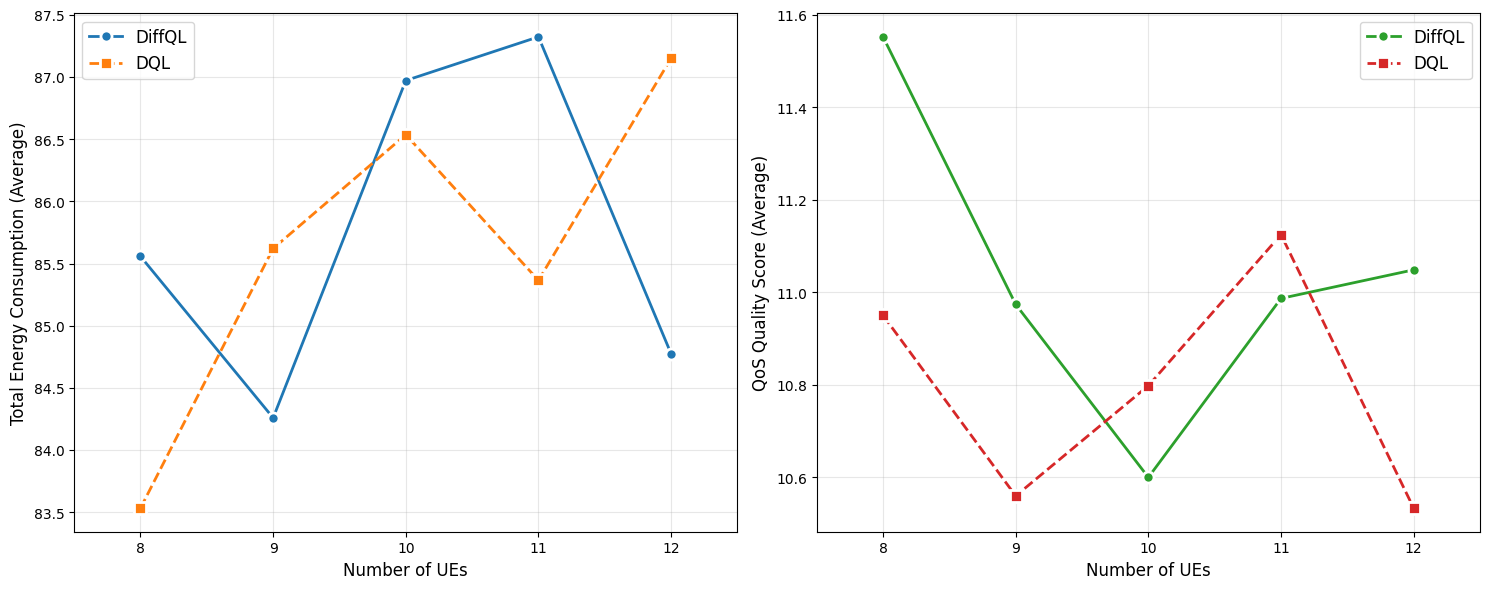


=== Detailed Metrics Comparison (Averaged over Epochs 201-500, Episode 4) ===
UE Config  Model    Energy Total QoS Quality  Completion Rate
----------------------------------------------------------------------
8          DiffQL   85.5578      11.5520      0.5443         
8          DQL      83.5332      10.9498      0.5125         

9          DiffQL   84.2592      10.9737      0.4586         
9          DQL      85.6210      10.5596      0.4660         

10         DiffQL   86.9715      10.5997      0.4264         
10         DQL      86.5359      10.7980      0.4231         

11         DiffQL   87.3227      10.9866      0.3919         
11         DQL      85.3648      11.1244      0.3785         

12         DiffQL   84.7743      11.0484      0.3456         
12         DQL      87.1502      10.5332      0.3534         



In [24]:
# Plot Energy Consumption and QoS Quality (Averaged over multiple epochs)
def plot_energy_and_qos_metrics(dql_metrics, gdql_metrics, start_epoch=491, end_epoch=500):
    """Plot energy consumption and QoS quality metrics averaged over multiple epochs"""
    
    # UE display range for 8-12 UEs
    ue_display = [8, 9, 10, 11, 12]
    
    # Initialize data arrays
    dql_energy = []
    dql_qos = []
    gdql_energy = []
    gdql_qos = []
    
    # Extract data for each UE number
    for ue_num in ue_display:
        ue_name = f"{ue_num}_ues"
        
        # Find DiffQL data (from /42 or /43 paths)
        dql_found = False
        for config_key in dql_metrics.keys():
            if config_key.startswith(f"{ue_num}_ues"):
                dql_energy.append(dql_metrics[config_key]['energy_total'])
                dql_qos.append(dql_metrics[config_key]['qos_quality_score_avg'])
                dql_found = True
                break
        if not dql_found:
            dql_energy.append(0)
            dql_qos.append(0)
        
        # Find DQL data (from /43 paths)
        gdql_found = False
        for config_key in gdql_metrics.keys():
            if config_key.startswith(f"{ue_num}_ues"):
                gdql_energy.append(gdql_metrics[config_key]['energy_total'])
                gdql_qos.append(gdql_metrics[config_key]['qos_quality_score_avg'])
                gdql_found = True
                break
        if not gdql_found:
            gdql_energy.append(0)
            gdql_qos.append(0)
    
    # Create figure with 2 subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))
    
    # Plot 1: Energy Consumption
    ax1.plot(ue_display, dql_energy, 'o-', color='#1f77b4', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#1f77b4', markeredgecolor='white', markeredgewidth=2)
    ax1.plot(ue_display, gdql_energy, 's--', color='#ff7f0e', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#ff7f0e', markeredgecolor='white', markeredgewidth=2)

    
    # ax1.set_title(f'Energy Consumption vs Number of UEs\n(Averaged over Epochs {start_epoch}-{end_epoch})', fontsize=14, fontweight='bold')
    ax1.set_xlabel('Number of UEs', fontsize=12)
    ax1.set_xlim(7.5, 12.5)
    ax1.set_ylabel('Total Energy Consumption (Average)', fontsize=12)
    ax1.grid(True, alpha=0.3)
    ax1.legend(fontsize=12)
    ax1.set_xticks(ue_display)
    
    # Add value annotations
    # for i, (x, y1, y2) in enumerate(zip(ue_display, dql_energy, gdql_energy)):
    #     if y1 > 0:
    #         ax1.annotate(f'{y1:.2f}', (x, y1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
    #     if y2 > 0:
    #         ax1.annotate(f'{y2:.2f}', (x, y2), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=10)
    
    # Plot 2: QoS Quality Score
    ax2.plot(ue_display, dql_qos, 'o-', color='#2ca02c', linewidth=2, markersize=8, 
             label='DiffQL', markerfacecolor='#2ca02c', markeredgecolor='white', markeredgewidth=2)
    ax2.plot(ue_display, gdql_qos, 's--', color='#d62728', linewidth=2, markersize=8, 
             label='DQL', markerfacecolor='#d62728', markeredgecolor='white', markeredgewidth=2)
    
    # ax2.set_title(f'QoS Quality Score vs Number of UEs\n(Averaged over Epochs {start_epoch}-{end_epoch})', fontsize=14, fontweight='bold')
    ax2.set_xlabel('Number of UEs', fontsize=12)
    ax2.set_xlim(7.5, 12.5)
    ax2.set_ylabel('QoS Quality Score (Average)', fontsize=12)
    ax2.grid(True, alpha=0.3)
    ax2.legend(fontsize=12)
    ax2.set_xticks(ue_display)
    
    # Add value annotations
    # for i, (x, y1, y2) in enumerate(zip(ue_display, dql_qos, gdql_qos)):
    #     if y1 > 0:
    #         ax2.annotate(f'{y1:.3f}', (x, y1), textcoords="offset points", xytext=(0,10), ha='center', fontsize=10)
    #     if y2 > 0:
    #         ax2.annotate(f'{y2:.3f}', (x, y2), textcoords="offset points", xytext=(0,-15), ha='center', fontsize=10)
    
    plt.tight_layout()
    plt.show()
    
    # Print detailed metrics table
    print(f"\n=== Detailed Metrics Comparison (Averaged over Epochs {start_epoch}-{end_epoch}, Episode {EPISODE}) ===")
    print(f"{'UE Config':<10} {'Model':<8} {'Energy Total':<12} {'QoS Quality':<12} {'Completion Rate':<15}")
    print("-" * 70)
    
    for i, ue_num in enumerate(ue_display):
        # Print DiffQL data
        dql_config_found = None
        for config_key in dql_metrics.keys():
            if config_key.startswith(f"{ue_num}_ues"):
                dql_config_found = config_key
                break
        
        if dql_config_found:
            print(f"{ue_num:<10} {'DiffQL':<8} {dql_metrics[dql_config_found]['energy_total']:<12.4f} "
                  f"{dql_metrics[dql_config_found]['qos_quality_score_avg']:<12.4f} "
                  f"{dql_metrics[dql_config_found]['completion_rate']:<15.4f}")
        
        # Print DQL data
        gdql_config_found = None
        for config_key in gdql_metrics.keys():
            if config_key.startswith(f"{ue_num}_ues"):
                gdql_config_found = config_key
                break
                
        if gdql_config_found:
            print(f"{ue_num:<10} {'DQL':<8} {gdql_metrics[gdql_config_found]['energy_total']:<12.4f} "
                  f"{gdql_metrics[gdql_config_found]['qos_quality_score_avg']:<12.4f} "
                  f"{gdql_metrics[gdql_config_found]['completion_rate']:<15.4f}")
        print()

# Create the plots with epoch range information
plot_energy_and_qos_metrics(dql_metrics, gdql_metrics, START_EPOCH, END_EPOCH)